In [5]:
import pandas as pd

In [6]:
# Load dataset
df = pd.read_csv(r"C:\Users\KIIT0001\Downloads\archive (1)\train.csv")


In [7]:
print(df.head())

        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                   37                     4.9   
1  0xb379     BANGRES18DEL02                   34                     4.5   
2  0x5d6d     BANGRES19DEL01                   23                     4.4   
3  0x7a6a    COIMBRES13DEL02                   38                     4.7   
4  0x70a2     CHENRES12DEL01                   32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0   

In [8]:
print("\nShape of dataset:")
print(df.shape)


Shape of dataset:
(45593, 20)


In [9]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  V

In [10]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [11]:
print(df['Delivery_person_Age'].unique())

['37' '34' '23' '38' '32' '22' '33' '35' '36' '21' '24' '29' '25' '31'
 '27' '26' '20' 'NaN ' '28' '39' '30' '15' '50']


In [12]:
print(df['Delivery_person_Ratings'].unique())

['4.9' '4.5' '4.4' '4.7' '4.6' '4.8' '4.2' '4.3' '4' '4.1' '5' '3.5'
 'NaN ' '3.8' '3.9' '3.7' '2.6' '2.5' '3.6' '3.1' '2.7' '1' '3.2' '3.3'
 '6' '3.4' '2.8' '2.9' '3']


In [16]:
print(df['multiple_deliveries'].unique())

[ 0.  1.  3. nan  2.]


In [17]:
print(df['Time_taken(min)'].unique()[:10])

[24 33 26 21 30 40 32 34 46 23]


In [15]:
# Replace string 'NaN ' with actual null values
df['Delivery_person_Age'] = df['Delivery_person_Age'].replace('NaN ', pd.NA)

df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].replace('NaN ', pd.NA)

df['multiple_deliveries'] = df['multiple_deliveries'].replace('NaN ', pd.NA)

# Clean time taken column
df['Time_taken(min)'] = (
    df['Time_taken(min)']
    .str.replace('(min) ', '', regex=False)
)

# Convert columns to numeric
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'])

df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'])

df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'])

df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'])

In [18]:
# Fill missing age with median
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(
    df['Delivery_person_Age'].median()
)

# Fill missing ratings with median
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(
    df['Delivery_person_Ratings'].median()
)

# Fill missing multiple deliveries with mode
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(
    df['multiple_deliveries'].mode()[0]
)

In [19]:
# Clean Weatherconditions column
df['Weatherconditions'] = (
    df['Weatherconditions']
    .str.replace('conditions ', '', regex=False)
    .str.strip()
)

# Remove extra spaces from categorical columns
categorical_cols = [
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City'
]

for col in categorical_cols:
    df[col] = df[col].str.strip()

In [20]:
print(df['Weatherconditions'].unique())

print(df['Road_traffic_density'].unique())

['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' 'NaN']
['High' 'Jam' 'Low' 'Medium' 'NaN']


In [33]:
# Replace fake NaN strings with actual missing values
df['Weatherconditions'] = df['Weatherconditions'].replace('NaN', pd.NA)

df['Road_traffic_density'] = df['Road_traffic_density'].replace('NaN', pd.NA)

In [34]:
# Fill with mode (most frequent value)
df['Weatherconditions'] = df['Weatherconditions'].fillna(
    df['Weatherconditions'].mode()[0]
)

df['Road_traffic_density'] = df['Road_traffic_density'].fillna(
    df['Road_traffic_density'].mode()[0]
)

In [23]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [24]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

# Extract useful time features
df['order_day'] = df['Order_Date'].dt.day_name()

df['order_month'] = df['Order_Date'].dt.month

df['order_weekday'] = df['Order_Date'].dt.weekday

In [25]:
print(df[['Order_Date', 'order_day', 'order_month']].head())

  Order_Date order_day  order_month
0 2022-03-19  Saturday            3
1 2022-03-25    Friday            3
2 2022-03-19  Saturday            3
3 2022-04-05   Tuesday            4
4 2022-03-26  Saturday            3


In [26]:
# Convert Time_Orderd to datetime time
df['Time_Orderd'] = pd.to_datetime(
    df['Time_Orderd'],
    format='%H:%M:%S',
    errors='coerce'
)

# Extract order hour
df['order_hour'] = df['Time_Orderd'].dt.hour

# Create peak hour flag
df['is_peak_hour'] = df['order_hour'].apply(
    lambda x: 1 if x in [12, 13, 19, 20, 21] else 0
)

In [27]:
print(df[['order_hour', 'is_peak_hour']].head(10))

   order_hour  is_peak_hour
0        11.0             0
1        19.0             1
2         8.0             0
3        18.0             0
4        13.0             1
5        21.0             1
6        19.0             1
7        17.0             0
8        20.0             1
9        21.0             1


Road_traffic_density
High      27.240000
Jam       31.176624
Low       21.464175
Medium    26.699644
Name: Time_taken(min), dtype: float64


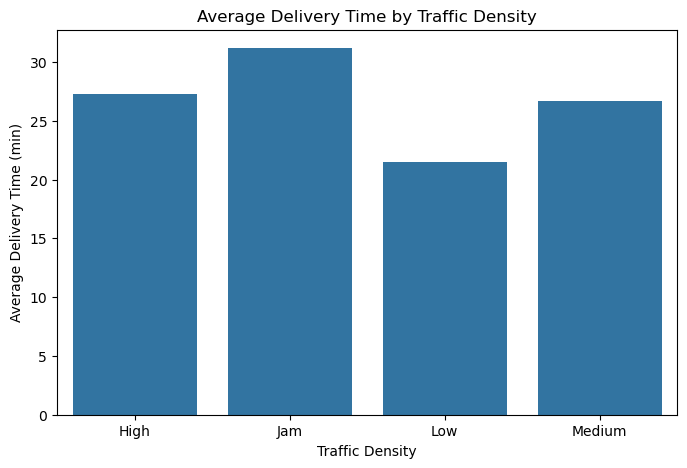

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average delivery time by traffic density
traffic_analysis = df.groupby('Road_traffic_density')['Time_taken(min)'].mean()

print(traffic_analysis)

# Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x=traffic_analysis.index,
    y=traffic_analysis.values
)

plt.title('Average Delivery Time by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Average Delivery Time (min)')

plt.show()


In [29]:
# Average delivery time by weather condition
weather_analysis = (
    df.groupby('Weatherconditions')['Time_taken(min)']
    .mean()
    .sort_values(ascending=False)
)

print(weather_analysis)


Weatherconditions
Cloudy        28.917330
Fog           28.739541
Windy         26.118836
Sandstorms    25.875517
Stormy        25.870815
Sunny         21.856947
Name: Time_taken(min), dtype: float64


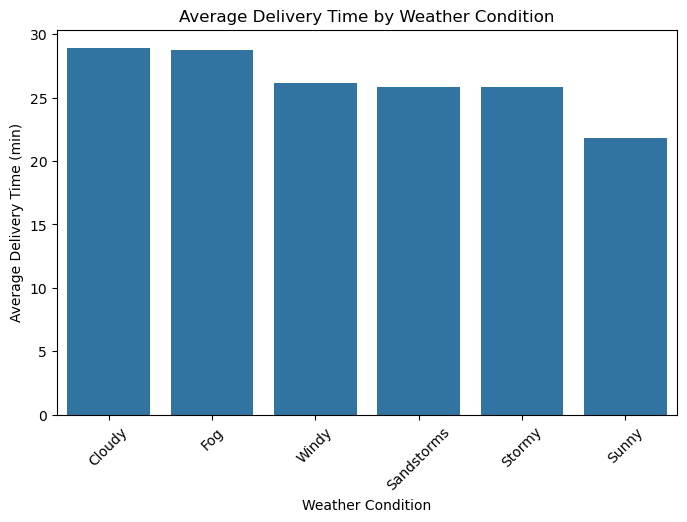

In [33]:

# Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x=weather_analysis.index,
    y=weather_analysis.values
)

plt.title('Average Delivery Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Delivery Time (min)')

plt.xticks(rotation=45)

plt.show()

In [36]:
from math import radians, cos, sin, asin, sqrt

# Function to calculate distance
def haversine(lat1, lon1, lat2, lon2):
    
    lon1, lat1, lon2, lat2 = map(
        radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        sin(dlat/2)**2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon/2)**2
    )

    c = 2 * asin(sqrt(a))

    r = 6371  # Radius of earth in km

    return c * r

# Create distance column
df['distance_km'] = df.apply(
    lambda x: haversine(
        x['Restaurant_latitude'],
        x['Restaurant_longitude'],
        x['Delivery_location_latitude'],
        x['Delivery_location_longitude']
    ),
    axis=1
)

In [40]:
print(df['distance_km'].head())

0     3.025149
1    20.183530
2     1.552758
3     7.790401
4     6.210138
Name: distance_km, dtype: float64


In [37]:
# Keep only realistic delivery distances
df = df[df['distance_km'] < 20]
print(df['distance_km'].describe())

count    43042.000000
mean         9.210301
std          5.208395
min          1.465067
25%          4.656945
50%          9.088005
75%         12.580268
max         19.976746
Name: distance_km, dtype: float64


Correlation: 0.3267105155368902


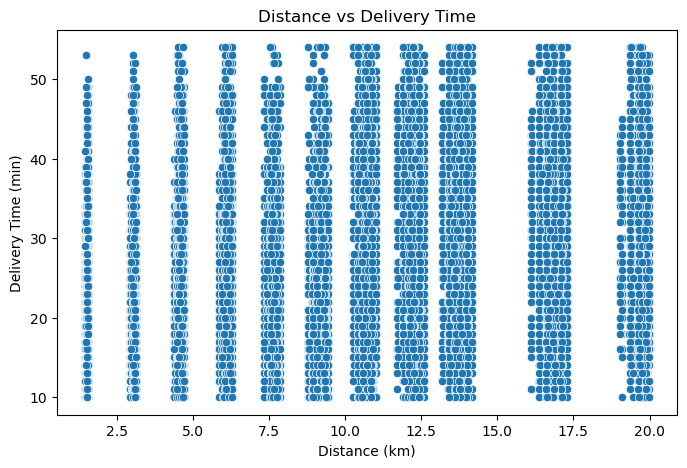

In [38]:
# Correlation between distance and delivery time
correlation = df['distance_km'].corr(df['Time_taken(min)'])

print("Correlation:", correlation)

# Scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['distance_km'],
    y=df['Time_taken(min)']
)

plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')

plt.show()

Type_of_vehicle
electric_scooter    24.306745
scooter             24.312973
bicycle             25.960000
motorcycle          27.434072
Name: Time_taken(min), dtype: float64


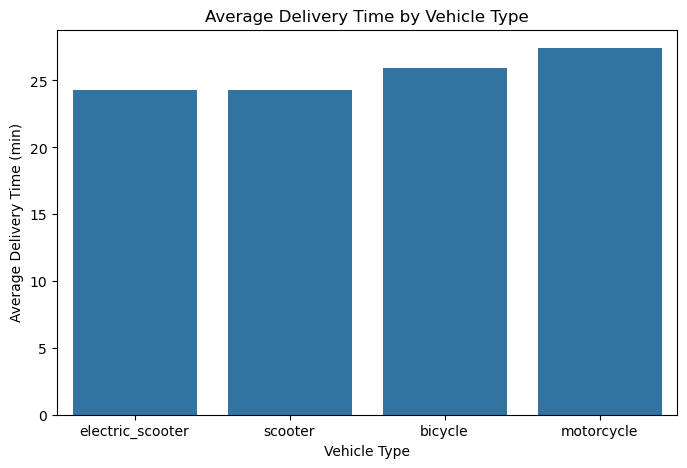

In [39]:
# Average delivery time by vehicle type
vehicle_analysis = (
    df.groupby('Type_of_vehicle')['Time_taken(min)']
    .mean()
    .sort_values()
)

print(vehicle_analysis)

# Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x=vehicle_analysis.index,
    y=vehicle_analysis.values
)

plt.title('Average Delivery Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Delivery Time (min)')

plt.show()

is_peak_hour
0    23.915942
1    30.465263
Name: Time_taken(min), dtype: float64


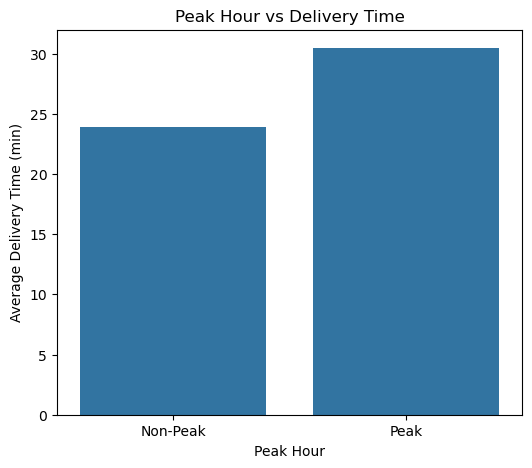

In [40]:
# Average delivery time during peak vs non-peak hours
peak_analysis = (
    df.groupby('is_peak_hour')['Time_taken(min)']
    .mean()
)

print(peak_analysis)

# Visualization
plt.figure(figsize=(6,5))

sns.barplot(
    x=peak_analysis.index,
    y=peak_analysis.values
)

plt.title('Peak Hour vs Delivery Time')
plt.xlabel('Peak Hour')
plt.ylabel('Average Delivery Time (min)')

plt.xticks([0,1], ['Non-Peak', 'Peak'])

plt.show()

Correlation: -0.3402727173777714


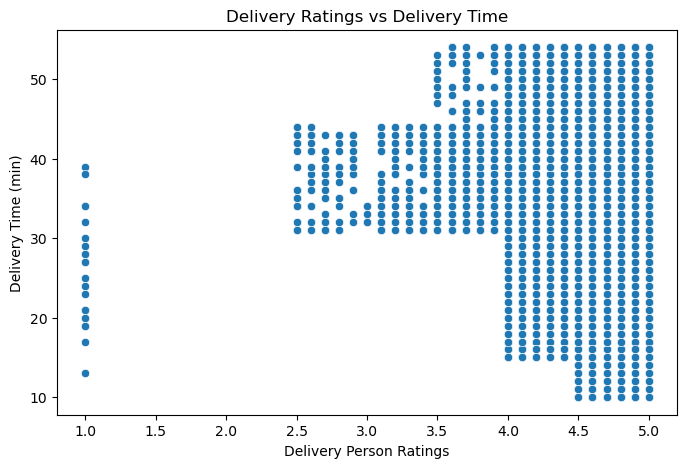

In [43]:
# Correlation between ratings and delivery time
correlation = df['Delivery_person_Ratings'].corr(df['Time_taken(min)'])

print("Correlation:", correlation)

# Scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Delivery_person_Ratings'],
    y=df['Time_taken(min)']
)

plt.title('Delivery Ratings vs Delivery Time')
plt.xlabel('Delivery Person Ratings')
plt.ylabel('Delivery Time (min)')

plt.show()

In [42]:
df = df[df['Delivery_person_Ratings'] <= 5]

In [44]:
print(df['Delivery_person_Ratings'].describe())

print(df[df['Delivery_person_Ratings'] == 6].shape[0])

df[df['Delivery_person_Ratings'] == 6].head()

count    43012.000000
mean         4.637148
std          0.318078
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64
0


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,multiple_deliveries,Festival,City,Time_taken(min),order_day,order_month,order_weekday,order_hour,is_peak_hour,distance_km


In [45]:
print(df['City'].unique())

['Urban' 'Metropolitian' 'Semi-Urban' 'NaN']


In [46]:
# Remove trailing spaces
df['City'] = df['City'].str.strip()
print(df['City'].unique())
print(df['City'].isnull().sum())

['Urban' 'Metropolitian' 'Semi-Urban' 'NaN']
0


In [47]:
# Replace fake NaN with actual missing value
df['City'] = df['City'].replace('NaN', pd.NA)

# Fill with most frequent city
df['City'] = df['City'].fillna(df['City'].mode()[0])

In [48]:
# Fix spelling inconsistency
df['City'] = df['City'].replace(
    'Metropolitian',
    'Metropolitan'
)

# Verify
print(df['City'].unique())

['Urban' 'Metropolitan' 'Semi-Urban']


City
Urban           22.873372
Metropolitan    26.962757
Semi-Urban      49.671141
Name: Time_taken(min), dtype: float64


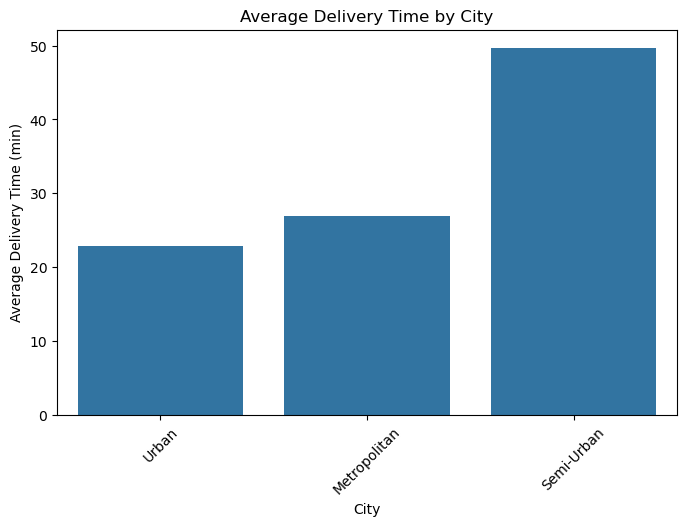

In [49]:
city_analysis = (
    df.groupby('City')['Time_taken(min)']
    .mean()
    .sort_values()
)

print(city_analysis)

plt.figure(figsize=(8,5))

sns.barplot(
    x=city_analysis.index,
    y=city_analysis.values
)

plt.title('Average Delivery Time by City')
plt.xlabel('City')
plt.ylabel('Average Delivery Time (min)')

plt.xticks(rotation=45)

plt.show()

multiple_deliveries
0.0    22.730962
1.0    26.581735
2.0    40.389439
3.0    47.798780
Name: Time_taken(min), dtype: float64


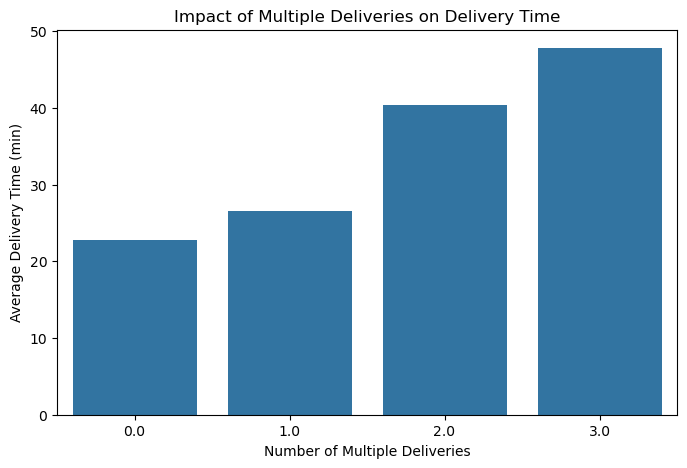

In [50]:
multiple_delivery_analysis = (
    df.groupby('multiple_deliveries')['Time_taken(min)']
    .mean()
    .sort_values()
)

print(multiple_delivery_analysis)

plt.figure(figsize=(8,5))

sns.barplot(
    x=multiple_delivery_analysis.index,
    y=multiple_delivery_analysis.values
)

plt.title('Impact of Multiple Deliveries on Delivery Time')
plt.xlabel('Number of Multiple Deliveries')
plt.ylabel('Average Delivery Time (min)')

plt.show()

In [51]:
print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'order_day', 'order_month', 'order_weekday', 'order_hour', 'is_peak_hour', 'distance_km']


In [52]:
# Convert Time_Orderd to datetime
df['Time_Orderd'] = pd.to_datetime(
    df['Time_Orderd'],
    format='%H:%M:%S',
    errors='coerce'
)

# Extract order hour
df['order_hour'] = df['Time_Orderd'].dt.hour

# Create peak hour flag
df['is_peak_hour'] = df['order_hour'].apply(
    lambda x: 1 if x in [12, 13, 19, 20, 21] else 0
)

In [53]:
print(df[['order_hour', 'is_peak_hour']].head())

   order_hour  is_peak_hour
0        11.0             0
2         8.0             0
3        18.0             0
4        13.0             1
5        21.0             1


In [54]:
peak_multi_analysis = pd.pivot_table(
    df,
    values='Time_taken(min)',
    index='multiple_deliveries',
    columns='is_peak_hour',
    aggfunc='mean'
)

print(peak_multi_analysis)

is_peak_hour                 0          1
multiple_deliveries                      
0.0                  21.130435  26.815769
1.0                  24.683161  30.212121
2.0                  38.977931  41.325709
3.0                  46.590909  48.241667


In [55]:
numeric_cols = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Vehicle_condition',
    'multiple_deliveries',
    'distance_km',
    'order_hour',
    'Time_taken(min)'
]

corr_matrix = df[numeric_cols].corr()

print(
    corr_matrix['Time_taken(min)']
    .sort_values(ascending=False)
)

Time_taken(min)            1.000000
multiple_deliveries        0.377722
distance_km                0.326742
Delivery_person_Age        0.297399
order_hour                 0.186404
Vehicle_condition         -0.237783
Delivery_person_Ratings   -0.340273
Name: Time_taken(min), dtype: float64


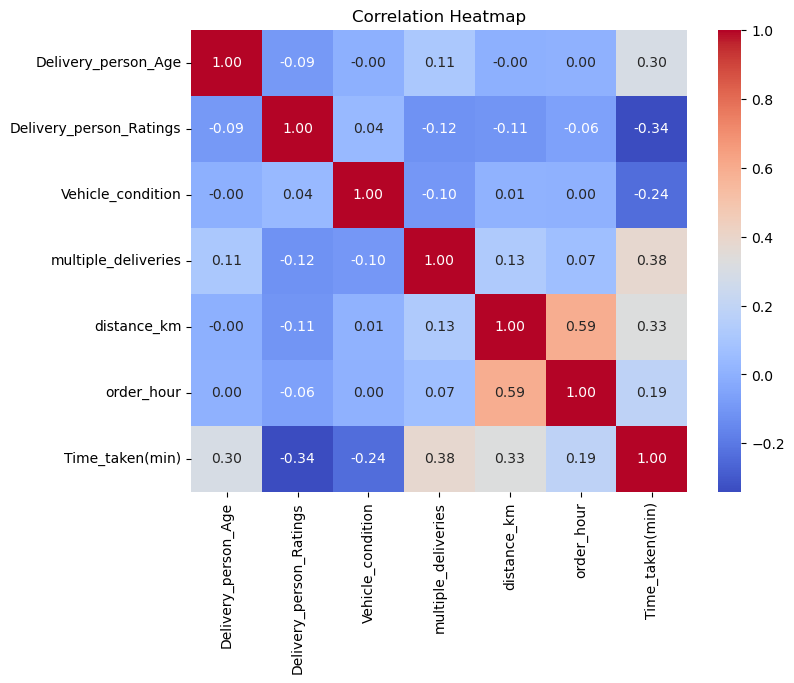

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [57]:
rating_multi = (
    df.groupby('multiple_deliveries')['Delivery_person_Ratings']
    .mean()
)

print(rating_multi)

multiple_deliveries
0.0    4.671415
1.0    4.635226
2.0    4.432068
3.0    4.536890
Name: Delivery_person_Ratings, dtype: float64


In [58]:
print(df['multiple_deliveries'].value_counts().sort_index())

multiple_deliveries
0.0    13381
1.0    27485
2.0     1818
3.0      328
Name: count, dtype: int64


In [59]:
traffic_weather = pd.pivot_table(
    df,
    values='Time_taken(min)',
    index='Road_traffic_density',
    columns='Weatherconditions',
    aggfunc='mean'
)

print(traffic_weather)

Weatherconditions        Cloudy        Fog  Sandstorms     Stormy      Sunny  \
Road_traffic_density                                                           
High                  28.951220  28.445596   27.703597  27.813953  23.401639   
Jam                   36.342567  36.541192   29.862084  29.875640  23.071059   
Low                   21.900240  22.704089   20.338554  20.719907  21.290323   
Medium                27.997673  27.636939   27.738535  27.555492  20.035098   

Weatherconditions         Windy  
Road_traffic_density             
High                  26.986339  
Jam                   30.153071  
Low                   20.722387  
Medium                27.828637  


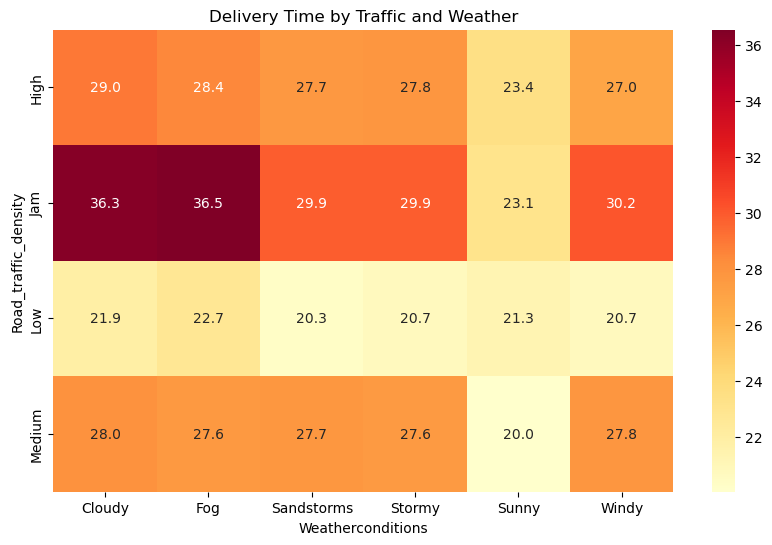

In [60]:
plt.figure(figsize=(10,6))

sns.heatmap(
    traffic_weather,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Delivery Time by Traffic and Weather')

plt.show()

In [62]:
partner_stats = (
    df.groupby('Delivery_person_ID')
      .agg({
          'Delivery_person_Ratings': 'mean',
          'Time_taken(min)': 'mean',
          'ID': 'count'
      })
      .rename(columns={'ID': 'total_orders'})
)

print(
    partner_stats
    .sort_values('total_orders', ascending=False)
    .head(10)
)

                    Delivery_person_Ratings  Time_taken(min)  total_orders
Delivery_person_ID                                                        
PUNERES01DEL01                     4.658209        27.925373            67
JAPRES11DEL02                      4.653731        28.597015            67
JAPRES03DEL01                      4.596970        27.030303            66
RANCHIRES02DEL01                   4.563636        26.924242            66
VADRES11DEL02                      4.606061        29.242424            66
INDORES08DEL02                     4.718462        24.676923            65
SURRES11DEL01                      4.656923        25.600000            65
INDORES15DEL01                     4.606154        27.369231            65
JAPRES09DEL02                      4.632308        26.738462            65
HYDRES04DEL02                      4.635385        27.215385            65


In [63]:
top_partners = (
    df.groupby('Delivery_person_ID')
      .agg({
          'Delivery_person_Ratings': 'mean',
          'Time_taken(min)': 'mean'
      })
      .sort_values(
          by=['Delivery_person_Ratings', 'Time_taken(min)'],
          ascending=[False, True]
      )
      .head(10)
)

print(top_partners)

                    Delivery_person_Ratings  Time_taken(min)
Delivery_person_ID                                          
LUDHRES20DEL03                     4.855556        20.111111
KOCRES13DEL01                      4.853333        27.866667
AGRRES19DEL02                      4.850000        28.375000
AURGRES13DEL03                     4.842857        25.428571
KNPRES04DEL02                      4.837500        25.375000
KOLRES14DEL01                      4.827273        22.909091
KOLRES19DEL02                      4.827273        32.454545
GOARES05DEL03                      4.825000        20.750000
AGRRES20DEL02                      4.818182        24.454545
GOARES12DEL01                      4.815385        22.000000


In [64]:
elite_partners = partner_stats[
    (partner_stats['Delivery_person_Ratings'] >= 4.7) &
    (partner_stats['Time_taken(min)'] <= 25) &
    (partner_stats['total_orders'] >= 30)
]

print(elite_partners.sort_values(
    by=['Delivery_person_Ratings', 'Time_taken(min)'],
    ascending=[False, True]
))

                    Delivery_person_Ratings  Time_taken(min)  total_orders
Delivery_person_ID                                                        
CHENRES09DEL03                     4.791892        24.513514            37
MUMRES16DEL03                      4.766667        24.466667            45
CHENRES01DEL02                     4.758696        23.173913            46
COIMBRES07DEL03                    4.758140        21.883721            43
BANGRES08DEL03                     4.744737        25.000000            38
MYSRES16DEL02                      4.744186        22.976744            43
BANGRES06DEL02                     4.727907        24.186047            43
VADRES02DEL01                      4.727778        24.796296            54
VADRES18DEL03                      4.727660        24.723404            47
MUMRES17DEL03                      4.721739        24.717391            46
COIMBRES18DEL03                    4.719048        24.547619            42
INDORES08DEL02           

In [65]:
kpis = {
    "Total Orders": len(df),
    "Average Delivery Time": round(df['Time_taken(min)'].mean(), 2),
    "Average Rating": round(df['Delivery_person_Ratings'].mean(), 2),
    "Average Distance (km)": round(df['distance_km'].mean(), 2),
    "Peak Hour Orders (%)": round(df['is_peak_hour'].mean() * 100, 2)
}

for k, v in kpis.items():
    print(f"{k}: {v}")

Total Orders: 43012
Average Delivery Time: 26.13
Average Rating: 4.64
Average Distance (km): 9.21
Peak Hour Orders (%): 33.8


In [66]:
print(df.shape)

(43012, 26)


In [67]:
df = df.copy()

In [68]:
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(
    df['multiple_deliveries'].median()
)

In [69]:
df = df.dropna(subset=['Time_Orderd', 'order_hour'])

In [70]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
order_hour                     0
is_peak_hour                   0
distance_km                    0
dtype: int64


In [71]:
print(df.dtypes)

ID                                     object
Delivery_person_ID                     object
Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                             object
Time_Orderd                    datetime64[ns]
Time_Order_picked                      object
Weatherconditions                      object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                   float64
Festival                               object
City                                   object
Time_taken(min)                         int64
order_hour                            float64
is_peak_hour                      

In [74]:
print(df['City'].unique())
print(df['Weatherconditions'].unique())
print(df['Road_traffic_density'].unique())
print(df['Type_of_vehicle'].unique())

['Urban' 'Metropolitan' 'Semi-Urban']
['Sunny' 'Sandstorms' 'Cloudy' 'Fog' 'Stormy' 'Windy']
['High' 'Low' 'Medium' 'Jam']
['motorcycle' 'scooter' 'electric_scooter']


In [75]:
print(df['Type_of_vehicle'].value_counts())

Type_of_vehicle
motorcycle          24216
scooter             13860
electric_scooter     3341
Name: count, dtype: int64


In [76]:
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Shape:", df.shape)

Total Missing Values: 0
Duplicate Rows: 0
Shape: (41417, 23)


In [77]:
print(df['Type_of_vehicle'].unique())

['motorcycle' 'scooter' 'electric_scooter']


In [78]:
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()

print(df['Type_of_vehicle'].unique())

['motorcycle' 'scooter' 'electric_scooter']


In [79]:
print(df.describe())

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count         41417.000000             41417.000000         41417.000000   
mean             29.559505                 4.636961            17.535764   
min              20.000000                 2.500000             0.000000   
25%              25.000000                 4.500000            12.939496   
50%              30.000000                 4.700000            18.569156   
75%              35.000000                 4.900000            22.732225   
max              39.000000                 5.000000            30.914057   
std               5.765862                 0.311343             7.208169   

       Restaurant_longitude  Delivery_location_latitude  \
count          41417.000000                41417.000000   
mean              71.022471                   17.595986   
min                0.000000                    0.010000   
25%               73.170000                   12.999496   
50%               75

In [80]:
print(df['Vehicle_condition'].value_counts())

print(df['Time_Orderd'].min())

print(df['Time_Orderd'].max())

print(df['Vehicle_condition'].value_counts())

print(df['Type_of_vehicle'].unique())

Vehicle_condition
1    13813
0    13805
2    13799
Name: count, dtype: int64
1900-01-01 00:00:00
1900-01-01 23:55:00
Vehicle_condition
1    13813
0    13805
2    13799
Name: count, dtype: int64
['motorcycle' 'scooter' 'electric_scooter']


In [81]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [82]:
print("Orders:", len(df))
print("Avg Time:", df['Time_taken(min)'].mean())
print("Avg Rating:", df['Delivery_person_Ratings'].mean())
print("Avg Distance:", df['distance_km'].mean())

Orders: 41417
Avg Time: 26.122823961175364
Avg Rating: 4.636960668324601
Avg Distance: 9.21132027037937


In [83]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
order_hour                     0
is_peak_hour                   0
distance_km                    0
dtype: int64


In [84]:
df.to_csv("food_delivery_cleaned.csv", index=False)

In [85]:
import os

print(os.path.exists("food_delivery_cleaned.csv"))

True


In [67]:
partner_performance = (
    df.groupby('Delivery_person_ID')
      .agg({
          'ID': 'count',
          'Time_taken(min)': 'mean'
      })
      .rename(columns={
          'ID': 'Total_Orders',
          'Time_taken(min)': 'Avg_Delivery_Time'
      })
      .reset_index()
)

print(partner_performance.head())

  Delivery_person_ID  Total_Orders  Avg_Delivery_Time
0    AGRRES010DEL01             13          25.230769
1    AGRRES010DEL02             15          28.800000
2    AGRRES010DEL03             10          26.400000
3     AGRRES01DEL01             11          27.545455
4     AGRRES01DEL02             14          24.428571


In [68]:
partner_stats.reset_index().to_csv("partner_stats.csv", index=False)

In [69]:
partner_stats['Partner_Category'] = 'Non-Elite'

partner_stats.loc[
    (partner_stats['Delivery_person_Ratings'] >= 4.7) &
    (partner_stats['Time_taken(min)'] <= 25) &
    (partner_stats['total_orders'] >= 30),
    'Partner_Category'
] = 'Elite'

In [70]:
elite_summary = (
    partner_stats['Partner_Category']
    .value_counts()
    .reset_index()
)

elite_summary.columns = ['Category', 'Count']

print(elite_summary)

    Category  Count
0  Non-Elite   1296
1      Elite     24


In [71]:
elite_summary.to_csv(
    r"C:\Users\KIIT0001\Downloads\elite_summary.csv",
    index=False
)